# KNN-MLP Results Plotter

This notebook fetches multiple Weights & Biases runs matching flexible config filters (including list-valued options), aggregates the selected metric across seeds, and plots mean with optional ranges (min/max, std, stderr). You can save figures as PDF/PNG. Edit the configuration cell to change filters, metric, and styling.

In [51]:
# Imports
import os

import numpy as np
import matplotlib.pyplot as plt
import wandb

import importlib

import wandb_plot_utils
importlib.reload(wandb_plot_utils)
from wandb_plot_utils import (
    plot_metric_over_epochs,
    save_current_figure,
    update_and_get_config_options,
    print_config_options,
    build_plot_filename,
    compute_global_metric_range,
)

In [52]:
# Project selection and available config options (run this first)
ENTITY = "haraghi"
PROJECT = "knn-mlp-order-all-intensity"
OPTIONS_CACHE_DIR = "cache"
CONFIG_KEYS_TO_SCAN = None    # e.g., ["lr", "k", "feature_type"] or None for all keys
UPDATE_CONFIG_OPTIONS = False # set True to refresh from server
MAX_RUNS_TO_SCAN = None       # optional limit for speed

try:
    api = wandb.Api()
    options = update_and_get_config_options(
        api=api,
        entity=ENTITY,
        project=PROJECT,
        cache_dir=OPTIONS_CACHE_DIR,
        force_refresh=UPDATE_CONFIG_OPTIONS,
        config_keys=CONFIG_KEYS_TO_SCAN,
        max_runs=MAX_RUNS_TO_SCAN,
    )
    print("Available config options with multiple values (from cache unless refreshed):")
    print_config_options(options, min_values=2)
except Exception as e:
    print(f"Error while retrieving config options: {e}")


Available config options with multiple values (from cache unless refreshed):
K:
  - 10
  - 100
  - 20
  - 200
  - 5
  - 50
dataset_config:
  - {'animation_fps': 10, 'animation_frame_step': 10, 'background_texture': None, 'bg_image_path': None, 'dtd_root': 'data/dtd/images', 'dtd_texture_mode': 'both', 'event_accumulation_ms': 10, 'event_animation_fps': 10, 'event_generation_method': 'intensity', 'fg_image_path': None, 'filter_size': 7, 'foreground_texture': None, 'frame_time_us': 1000, 'image_height': 256, 'image_width': 256, 'inner_radius': 20, 'intensity_neg_threshold': 0.05, 'intensity_pos_threshold': 0.05, 'intensity_shot_noise_rate_hz': 0, 'num_points': 5, 'number_of_rotations': 2, 'outer_radius': 40, 'random_seed': 0, 'shape_class': 'star8', 'tau': 30, 'total_frames': 2000, 'use_random_dtd_texture': False, 'v2e_bg_brightness': 1, 'v2e_bg_gamma': 0.6, 'v2e_cutoff_hz': 0, 'v2e_fg_brightness': 1, 'v2e_fg_gamma': 2, 'v2e_leak_jitter_fraction': 0, 'v2e_leak_rate_hz': 0, 'v2e_neg_thres

### Custom Label Names
Use the `LABEL_MAP` dictionary to provide human-readable labels for feature types:
```python
LABEL_MAP = {
    "original": "Original Features",
    "eig": "Eigenvalue Features",
    "filter": "Filter Features",
    "both": "Combined Features",
}
```
The mapping will automatically replace the internal names with your preferred labels in the legend.


In [53]:
# Custom label mapping for feature types
LABEL_MAP = {
    # original
    "original": "Baseline",
    "original_repeated_augmented": "Baseline + Repeated Concat.",
    "original_random_augmented": "Baseline + Random Concat.",
    "original_time_augmented": "Baseline + Rel. Time Concat.",
    # eig
    "eig": "w/ Eigenvalues",
    "eig_exclude_xy": "only Eigenvalues (no XY)",
    # filter
    "filter": "w/ Density values",
    "filter_exclude_xy": "only Density values (no XY)",
    # both
    "both": "w/ Eigenvalues + Density values",
    "both_time_augmented": "with Eigenvalues + Density + Rel. Time Concat.",
    "both_exclude_xy": "only Eigenvalues + Density values (no XY)",
}

# Custom color palette with distinct base colors for each group
# and distinguishable shades for variants within each group
COLOR_PALETTE_DICT = {
    # Original group (Blue tones)
    "original": "#0055AA",                      # Deep blue
    "original_repeated_augmented": "#4A90E2",   # Medium blue
    "original_random_augmented": "#7AB8FF",     # Light blue
    "original_time_augmented": "#A8D4FF",       # Very light blue
    
    # Eig group (Purple/Magenta tones)
    "eig": "#7B2D8E",                           # Deep purple
    "eig_exclude_xy": "#AA5FC2",                # Medium purple
    
    # Filter group (Green tones)
    "filter": "#117733",                        # Deep green
    "filter_exclude_xy": "#44AA66",             # Light green
    
    # Both group (Red/Orange tones)
    "both": "#CC3311",                          # Deep red
    "both_time_augmented": "#FF6B4A",           # Light red/coral
    "both_exclude_xy": "#FFAA99",               # Very light red
}


In [54]:
# Configuration: choose filters and plotting options

# Plot controls
METRIC = "val_loss"              # metric key in W&B history, e.g., "val_loss"
RANGE_TYPE = "std"               # "minmax" | "std" | "stderr" | "none"
INCLUDE_FILL = True
ALPHA = 0.25                     # transparency for fill_between
LINEWIDTH = 2.0
FIGSIZE = (8, 5)
GRID = True
SHOW_LEGEND = True

# Color control for consistent mapping by config key (e.g., feature_type)
COLOR_BY_KEY = "feature_type"    # set to None to disable color mapping by key

# Font sizes for publication-quality figures
FONTSIZE_TITLE = 14
FONTSIZE_LABELS = 16
FONTSIZE_TICKS = 14
FONTSIZE_LEGEND = 14

# Caching controls
USE_CACHE = True                 # if True, load from cache when available
REFRESH_CACHE = False            # if True, refetch from W&B and overwrite cache
CACHE_DIR = "cache"

# Saving controls
SAVE_DIR = "outputs"  # where to save figures
SAVE_NAME = None                     # optional override; if None, name is auto-built from config
SAVE_PDF = False
SAVE_PNG = False
ADD_TIMESTAMP = False               # do not add time; filenames are configuration-specific

## Notes

- To compare multiple settings on the same plot, set list-valued entries in `CONFIG_FILTER` (e.g., `"k": [10, 50, 100]`, `"lr": [1e-4, 5e-5]`). All combinations are plotted with separate lines.
- Choose `RANGE_TYPE` among `"minmax"`, `"std"`, `"stderr"`, or `"none"` for the shaded area around the mean. Toggle shading with `INCLUDE_FILL`.
- Set `SAVE_PDF=True` to export vector graphics; `SAVE_PNG=True` for raster. Files save to `SAVE_DIR` with the base `SAVE_NAME`.
- If you see "No runs" messages, adjust `CONFIG_FILTER` to match your W&B runs (entity/project must be correct).
- You can change `METRIC` to any history key logged in your runs (e.g., `"train_loss"`).

### Publication-Quality Font Sizes
Adjust the following parameters for better readability in publications:
- `FONTSIZE_TITLE`: Title font size (default: 16)
- `FONTSIZE_LABELS`: X and Y axis labels font size (default: 14)
- `FONTSIZE_TICKS`: Tick labels font size (default: 12)
- `FONTSIZE_LEGEND`: Legend font size (default: 12)

For papers, consider using larger values like `FONTSIZE_TITLE=18`, `FONTSIZE_LABELS=16`, `FONTSIZE_TICKS=14`.

### Consistent Y-Axis for Batch Comparisons
The batch generation section automatically computes a global y-axis range across all figures to enable easy visual comparison. The `compute_global_metric_range()` function:
1. Scans all configurations in the batch
2. Finds the global min/max values (including error bands)
3. Adds a 5% margin
4. Applies the same y-axis limits to all plots

This ensures all subfigures are on the same scale, making it easy to compare performance across different hyperparameter settings.

## Batch generation: 6 figures for hidden_dim × k

This section generates one figure per combination of hidden_dim and k ∈ {5, 10, 50}. Each figure plots feature_type ∈ [original, eig, filter, both] with consistent colors based on feature_type.

**Important:** All figures in this batch share the same y-axis range for easy comparison. The global min/max is computed across all configurations before plotting begins.

Computing global y-axis range for consistent scaling...
Global y-axis range: [0.0000, 0.1200]
Saved: main_4__hidden_dim=64__k=5 (.pdf/.png) -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


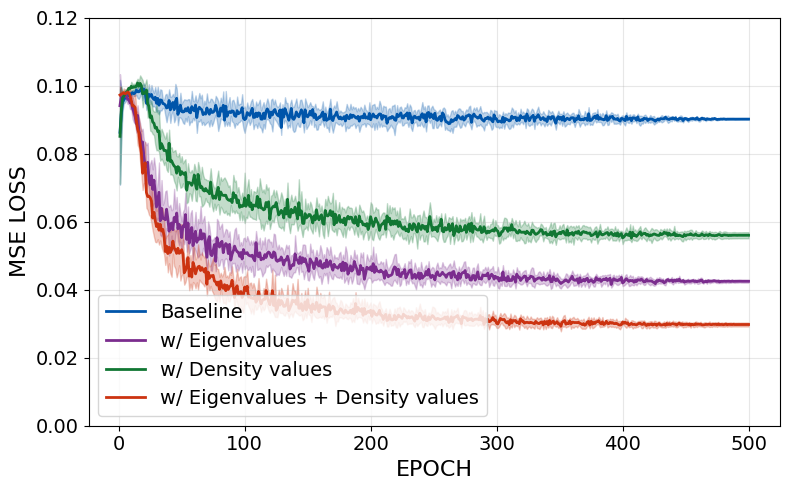

Saved: main_4__hidden_dim=64__k=10 (.pdf/.png) -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


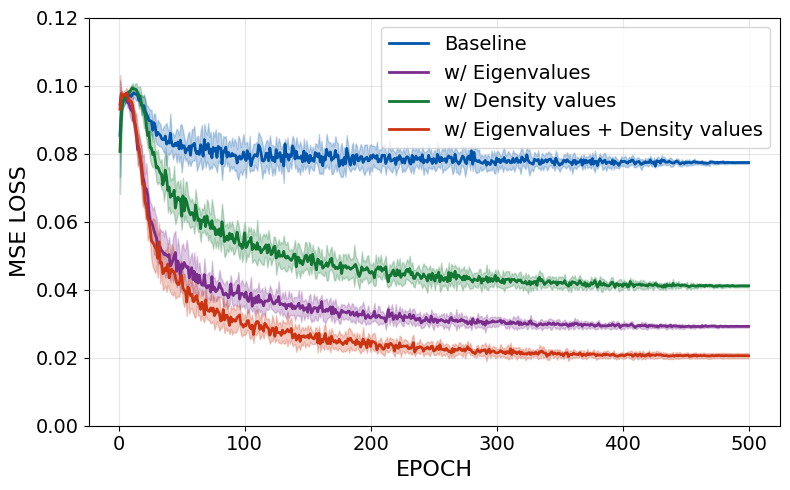

Saved: main_4__hidden_dim=64__k=50 (.pdf/.png) -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


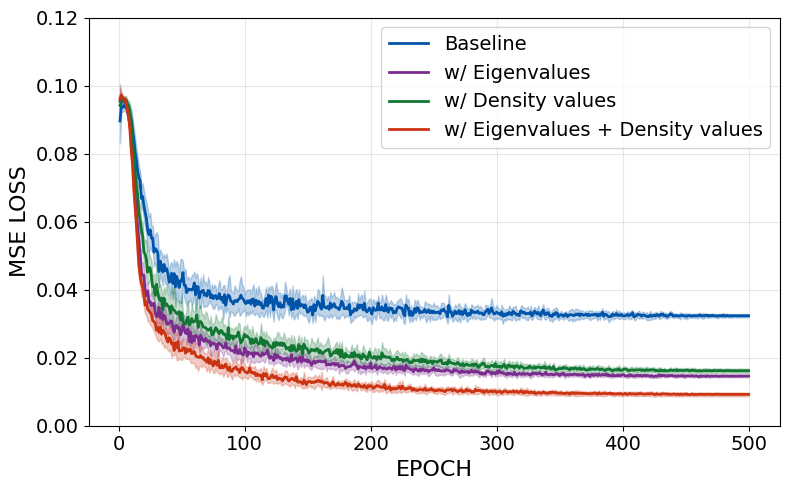

Saved: main_4__hidden_dim=128__k=5 (.pdf/.png) -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


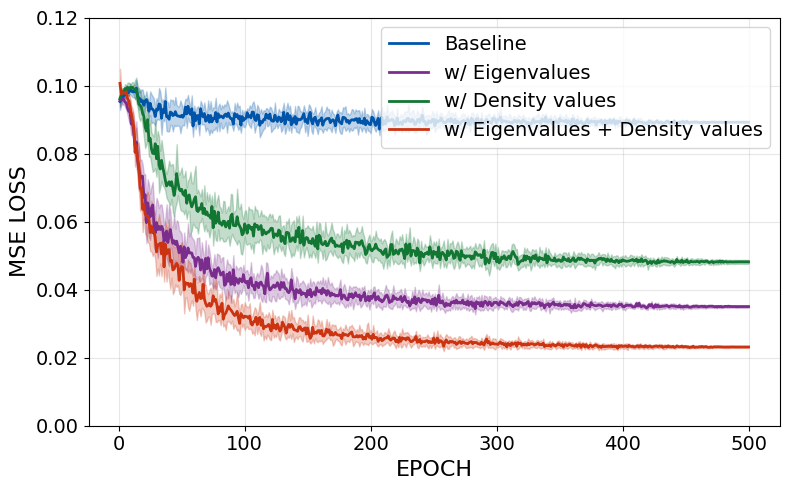

Saved: main_4__hidden_dim=128__k=10 (.pdf/.png) -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


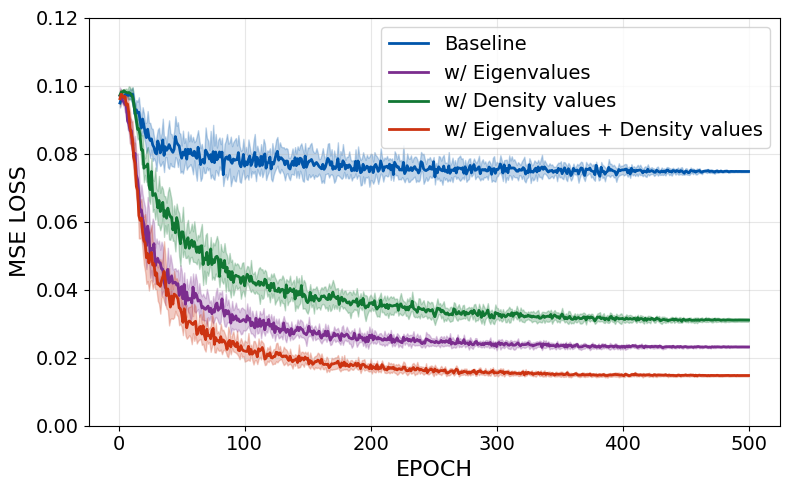

Saved: main_4__hidden_dim=128__k=50 (.pdf/.png) -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


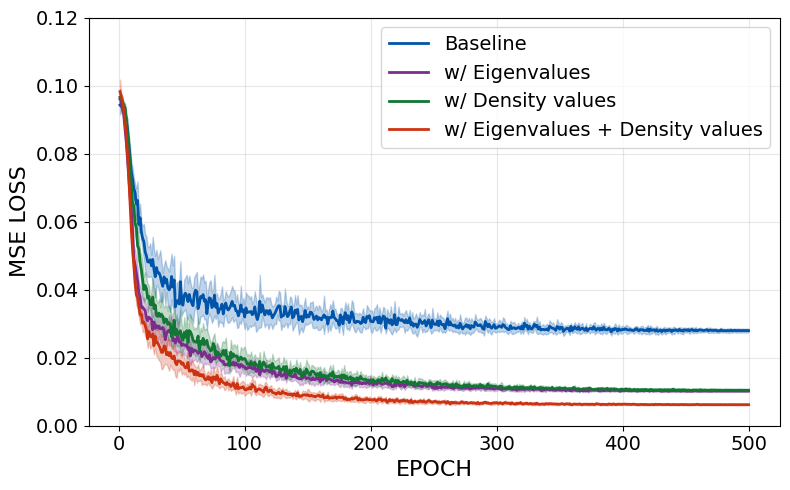

In [ ]:
# Batch: generate 6 figures for combinations of hidden_dim and k
 
# Adjust the hidden dimensions here (two values recommended for 6 figures with k=[5,10,50])
HIDDEN_DIMS = [64, 128]  # change as needed
K_LIST = [5, 10, 50]  # change as needed
FEATURE_TYPES = ["original", "eig", "filter", "both"]
SAVE_PDF = True
SAVE_DIR = os.path.join("outputs", "toydataset_order_mlp")
try:
    api = wandb.Api()
    
    # Step 1: Collect all configurations for this batch
    all_configs = []
    for hd in HIDDEN_DIMS:
        for k in K_LIST:
            all_configs.append({
                # "test_train_split": "temporal",
                # "lr": 1e-3,
                # "max_epochs": 500,
                "hidden_dim": hd,
                "k": k,
                "feature_type": FEATURE_TYPES,
            })
    
    # Step 2: Compute global y-axis range across all configurations
    print("Computing global y-axis range for consistent scaling...")
    from itertools import product
    flat_configs = []
    for cfg in all_configs:
        # Expand feature_type list into individual configs
        for ft in cfg["feature_type"]:
            flat_cfg = cfg.copy()
            flat_cfg["feature_type"] = ft
            flat_configs.append(flat_cfg)
    
    global_ymin, global_ymax = compute_global_metric_range(
        api=api,
        entity=ENTITY,
        project=PROJECT,
        config_list=flat_configs,
        metric=METRIC,
        range_type=RANGE_TYPE,
        use_cache=USE_CACHE,
        refresh_cache=REFRESH_CACHE,
        cache_dir=CACHE_DIR,
        margin=0.05,  # 5% margin
    )
    global_ymin = 0.0  # force ymin to 0 for loss plots
    global_ymax = 0.12 
    if global_ymin is not None and global_ymax is not None:
        print(f"Global y-axis range: [{global_ymin:.4f}, {global_ymax:.4f}]")
    else:
        print("Could not compute global range, using auto-scaling per plot")
    
    # Step 3: Generate figures with consistent y-axis
    for hd in HIDDEN_DIMS:
        for k in K_LIST:
            base_filter = {
                # "test_train_split": "temporal",
                # "lr": 1e-3,
                # "max_epochs": 500,
                "hidden_dim": hd,
                "k": k,
                # Plot all feature types in this figure
                "feature_type": FEATURE_TYPES,
            }


            # Plot figure
            plot_metric_over_epochs(
                api=api,
                entity=ENTITY,
                project=PROJECT,
                base_filter=base_filter,
                metric=METRIC,
                range_type=RANGE_TYPE,
                include_fill=INCLUDE_FILL,
                alpha=ALPHA,
                linewidth=LINEWIDTH,
                figsize=FIGSIZE,
                # title=f"hidden_dim = {hd}, $k$ = {k}",
                title=None,
                grid=GRID,
                show_legend=SHOW_LEGEND,
                color_by_key="feature_type",
                color_palette=COLOR_PALETTE_DICT,
                label_map=LABEL_MAP,
                fontsize_title=FONTSIZE_TITLE,
                fontsize_labels=FONTSIZE_LABELS,
                fontsize_ticks=FONTSIZE_TICKS,
                fontsize_legend=FONTSIZE_LEGEND,
                ylim=(global_ymin, global_ymax) if global_ymin is not None else None,
                x_axis="epoch",
                x_label="EPOCH",
                y_label="MSE LOSS",
                legend_loc='best',
                use_cache=USE_CACHE,
                refresh_cache=REFRESH_CACHE,
                cache_dir=CACHE_DIR,
            )


            # Auto filename from config (no timestamp)
            # auto_name = build_plot_filename(
            #     base_filter=base_filter,
            #     metric=METRIC,
            #     range_type=RANGE_TYPE,
            #     color_by_key=None,
            #     prefix=None,
            # )
            if SAVE_PDF or SAVE_PNG:
                save_current_figure(
                    save_dir=SAVE_DIR,
                    save_name=f"main_4__hidden_dim={hd}__k={k}",
                    save_png=SAVE_PNG,
                    save_pdf=SAVE_PDF,
                    timestamp=False,
                )
                print(f"Saved: main_4__hidden_dim={hd}__k={k} (.pdf/.png) -> {os.path.abspath(SAVE_DIR)}")


            plt.show()
            plt.close()
except Exception as e:
    print(f"Batch generation error: {e}")

## original_repeated_XY

Saved figure(s) as 'original_repeated_XY.pdf/png' to /data/idnet/toy_datasets/outputs/toydataset_order_mlp


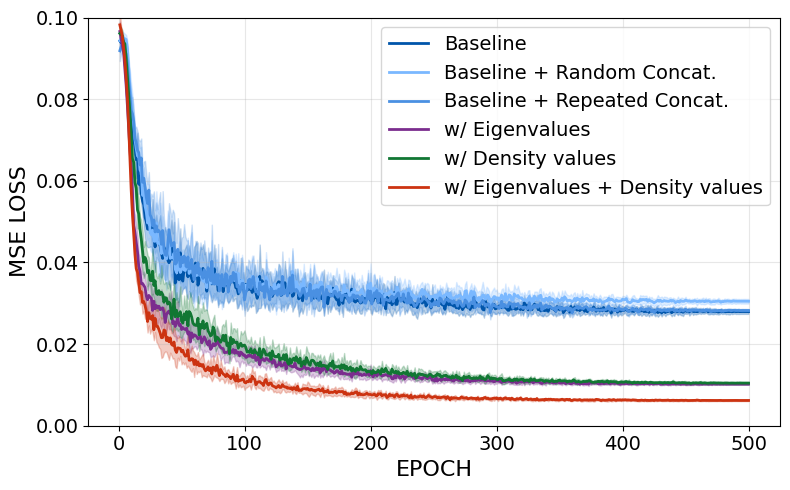

In [56]:
SAVE_PDF = True
SAVE_DIR = os.path.join("outputs", "toydataset_order_mlp")

FEATURE_TYPES_SPECIFIC = [
    "original",
    "original_random_augmented",
    "original_repeated_augmented",
    "eig",
    "filter",
    "both",
]

try:
    api = wandb.Api()
    base_filter = {
        # "test_train_split": "temporal",
        # "lr": 1e-4,
        # "max_epochs": 200,
        "hidden_dim": 128,
        "k": 50,
        "feature_type": FEATURE_TYPES_SPECIFIC,
    }

    plot_metric_over_epochs(
        api=api,
        entity=ENTITY,
        project=PROJECT,
        base_filter=base_filter,
        metric=METRIC,
        range_type=RANGE_TYPE,
        include_fill=INCLUDE_FILL,
        alpha=ALPHA,
        linewidth=LINEWIDTH,
        figsize=FIGSIZE,
        # title=f"{METRIC} vs Epoch | hidden_dim=128, k=50",
        grid=GRID,
        show_legend=SHOW_LEGEND,
        color_by_key="feature_type",
        color_palette=COLOR_PALETTE_DICT,
        label_map=LABEL_MAP,
        fontsize_title=FONTSIZE_TITLE,
        fontsize_labels=FONTSIZE_LABELS,
        fontsize_ticks=FONTSIZE_TICKS,
        fontsize_legend=FONTSIZE_LEGEND,
        use_cache=USE_CACHE,
        refresh_cache=REFRESH_CACHE,
        cache_dir=CACHE_DIR,
        ylim=(0.0, 0.1),
        x_axis="epoch",
        x_label="EPOCH",
        y_label="MSE LOSS",
        legend_loc='best',
    )

    # auto_name = build_plot_filename(
    #     base_filter=base_filter,
    #     metric=METRIC,
    #     range_type=RANGE_TYPE,
    #     color_by_key="feature_type",
    #     prefix="specific",
    # )
    # selected_name = SAVE_NAME if SAVE_NAME else auto_name

    if SAVE_PNG or SAVE_PDF:
        save_current_figure(
            save_dir=SAVE_DIR,
            save_name="original_repeated_XY",
            save_png=SAVE_PNG,
            save_pdf=SAVE_PDF,
            timestamp=False,
        )
        print(f"Saved figure(s) as 'original_repeated_XY.pdf/png' to {os.path.abspath(SAVE_DIR)}")

    plt.show()
except Exception as e:
    print(f"Error during specific figure plotting: {e}")

## exclude xy

Saved figure(s) as 'exclude_XY.pdf/png' to /data/idnet/toy_datasets/outputs/toydataset_order_mlp


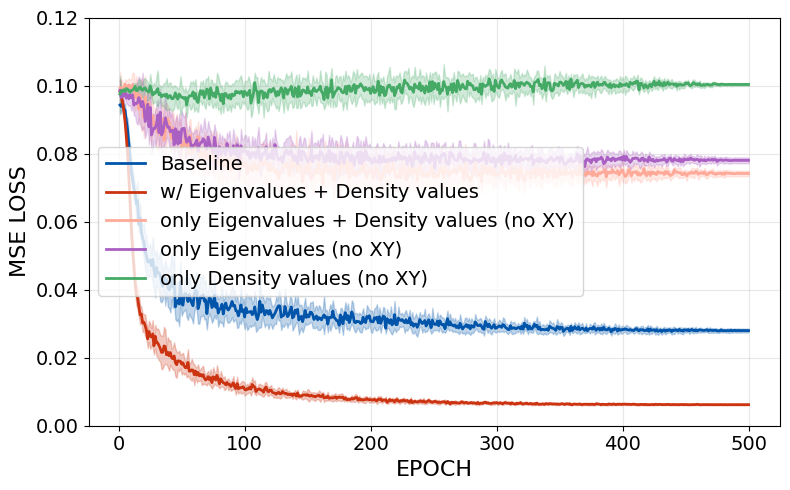

In [57]:
SAVE_PDF = True
SAVE_DIR = os.path.join("outputs", "toydataset_order_mlp")

FEATURE_TYPES_EXCLUDE_XY = [
    "original",
    "both",
    "both_exclude_xy",
    "eig_exclude_xy",
    "filter_exclude_xy",
]

try:
    api = wandb.Api()
    base_filter = {
        # "test_train_split": "temporal",
        # "lr": 1e-4,
        # "max_epochs": 200,
        "hidden_dim": 128,
        "k": 50,
        "feature_type": FEATURE_TYPES_EXCLUDE_XY,
    }

    plot_metric_over_epochs(
        api=api,
        entity=ENTITY,
        project=PROJECT,
        base_filter=base_filter,
        metric=METRIC,
        range_type=RANGE_TYPE,
        include_fill=INCLUDE_FILL,
        alpha=ALPHA,
        linewidth=LINEWIDTH,
        figsize=FIGSIZE,
        # title=f"hidden_dim=128, k=50 (exclude xy)",
        grid=GRID,
        show_legend=SHOW_LEGEND,
        color_by_key="feature_type",
        color_palette=COLOR_PALETTE_DICT,
        label_map=LABEL_MAP,
        fontsize_title=FONTSIZE_TITLE,
        fontsize_labels=FONTSIZE_LABELS,
        fontsize_ticks=FONTSIZE_TICKS,
        fontsize_legend=FONTSIZE_LEGEND,
        use_cache=USE_CACHE,
        refresh_cache=REFRESH_CACHE,
        cache_dir=CACHE_DIR,
        ylim=(0.0, 0.12),
        x_axis="epoch",
        x_label="EPOCH",
        y_label="MSE LOSS",
        legend_loc='best',
    )

    # auto_name = build_plot_filename(
    #     base_filter=base_filter,
    #     metric=METRIC,
    #     range_type=RANGE_TYPE,
    #     color_by_key="feature_type",
    #     # prefix="specific_exclude_xy",
    # )
    # selected_name = SAVE_NAME if SAVE_NAME else auto_name

    if SAVE_PNG or SAVE_PDF:
        save_current_figure(
            save_dir=SAVE_DIR,
            save_name="exclude_XY",
            save_png=SAVE_PNG,
            save_pdf=SAVE_PDF,
            timestamp=False,
        )
        print(f"Saved figure(s) as 'exclude_XY.pdf/png' to {os.path.abspath(SAVE_DIR)}")

    plt.show()
except Exception as e:
    print(f"Error during specific exclude_xy plotting: {e}")

Saved: time_aug_k=5 -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


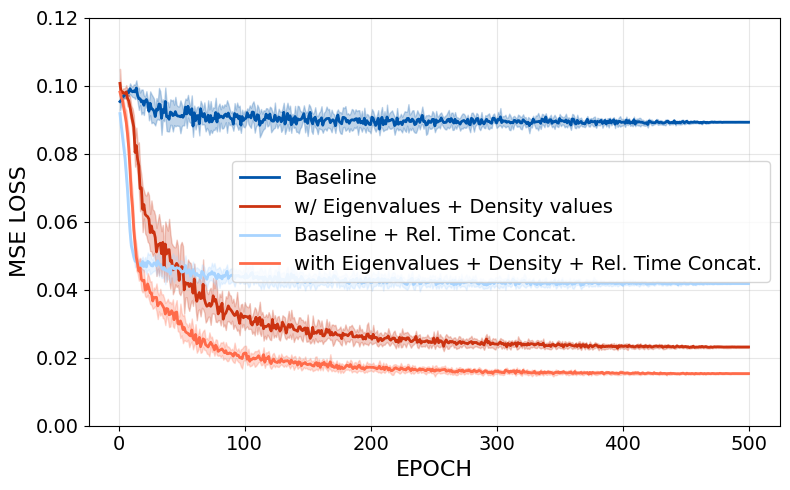

Saved: time_aug_k=10 -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


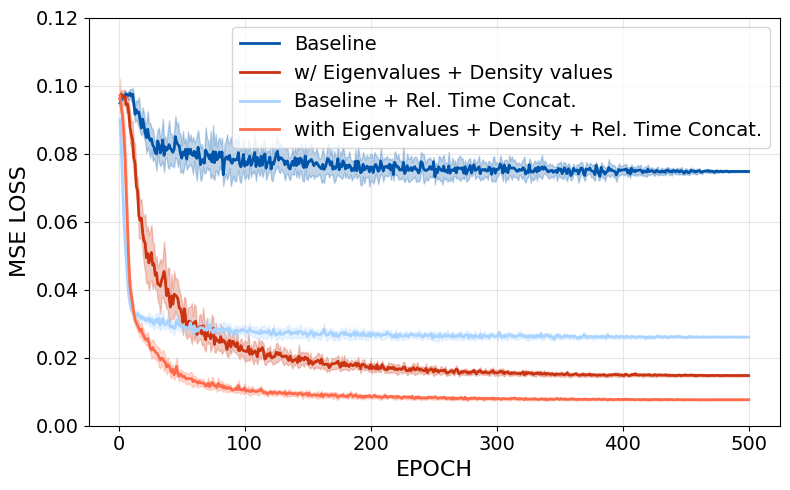

Saved: time_aug_k=50 -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


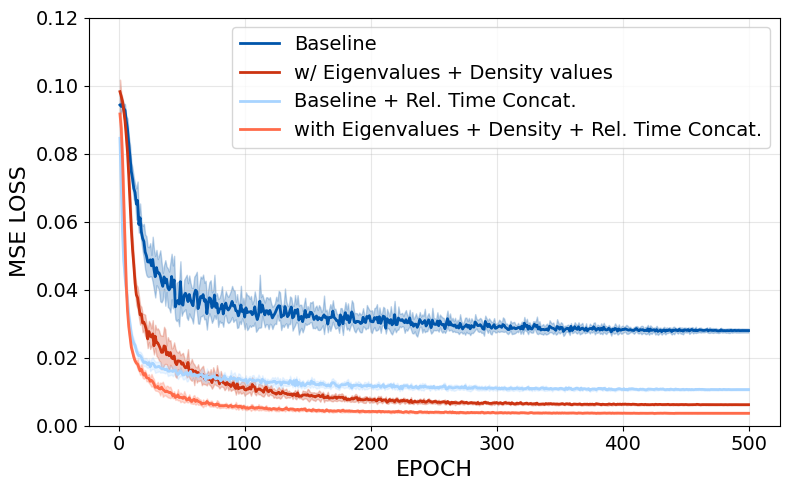

In [58]:
SAVE_PDF = True
SAVE_DIR = os.path.join("outputs", "toydataset_order_mlp")

FEATURE_TYPES_TIMEAUG = [
    "original", 
    # "filter", 
    # "eig", 
    "both", 
    "original_time_augmented", 
    "both_time_augmented"
]
K_LIST_TIMEAUG = [5, 10, 50]

try:
    api = wandb.Api()
    
    # Step 1: Collect all configurations for this batch
    all_configs_timeaug = []
    for k_val in K_LIST_TIMEAUG:
        all_configs_timeaug.append({
            # "test_train_split": "temporal",
            # "lr": 1e-4,
            # "max_epochs": 500,
            "hidden_dim": 128,
            "k": k_val,
            "feature_type": FEATURE_TYPES_TIMEAUG,
        })
    
    # Step 2: Compute global y-axis range across all time-aug configurations
    # print("Computing global y-axis range for time-augmentation figures...")
    # flat_configs_timeaug = []
    # for cfg in all_configs_timeaug:
    #     # Expand feature_type list into individual configs
    #     for ft in cfg["feature_type"]:
    #         flat_cfg = cfg.copy()
    #         flat_cfg["feature_type"] = ft
    #         flat_configs_timeaug.append(flat_cfg)
    
    # global_ymin_timeaug, global_ymax_timeaug = compute_global_metric_range(
    #     api=api,
    #     entity=ENTITY,
    #     project=PROJECT,
    #     config_list=flat_configs_timeaug,
    #     metric=METRIC,
    #     range_type=RANGE_TYPE,
    #     use_cache=USE_CACHE,
    #     refresh_cache=REFRESH_CACHE,
    #     cache_dir=CACHE_DIR,
    #     margin=0.05,  # 5% margin
    # )
    
    # if global_ymin_timeaug is not None and global_ymax_timeaug is not None:
    #     print(f"Global y-axis range for time-aug: [{global_ymin_timeaug:.4f}, {global_ymax_timeaug:.4f}]")
    # else:
    #     print("Could not compute global range, using auto-scaling per plot")
    
    # Step 3: Generate figures with consistent y-axis
    for k_val in K_LIST_TIMEAUG:
        base_filter = {
            # "test_train_split": "temporal",
            # "lr": 1e-4,
            # "max_epochs": 500,
            "hidden_dim": 128,
            "k": k_val,
            "feature_type": FEATURE_TYPES_TIMEAUG,
        }

        # Plot figure for this k
        plot_metric_over_epochs(
            api=api,
            entity=ENTITY,
            project=PROJECT,
            base_filter=base_filter,
            metric=METRIC,
            range_type=RANGE_TYPE,
            include_fill=INCLUDE_FILL,
            alpha=ALPHA,
            linewidth=LINEWIDTH,
            figsize=FIGSIZE,
            # title=f"hidden_dim=128, k={k_val} (time concat.)",
            grid=GRID,
            show_legend=SHOW_LEGEND,
            color_by_key="feature_type",
            color_palette=COLOR_PALETTE_DICT,
            label_map=LABEL_MAP,
            fontsize_title=FONTSIZE_TITLE,
            fontsize_labels=FONTSIZE_LABELS,
            fontsize_ticks=FONTSIZE_TICKS,
            fontsize_legend=FONTSIZE_LEGEND,
            # ylim=(global_ymin_timeaug, global_ymax_timeaug) if global_ymin_timeaug is not None else None,
            ylim=(0.0, 0.12),
            use_cache=USE_CACHE,
            refresh_cache=REFRESH_CACHE,
            cache_dir=CACHE_DIR,
            x_axis="epoch",
            x_label="EPOCH",
            y_label="MSE LOSS",
            legend_loc='best',
        )

        # Save using deterministic name
        # auto_name = build_plot_filename(
        #     base_filter=base_filter,
        #     metric=METRIC,
        #     range_type=RANGE_TYPE,
        #     color_by_key="feature_type",
        #     prefix=f"specific_timeaug_k{k_val}",
        # )
        # selected_name = SAVE_NAME if SAVE_NAME else auto_name

        if SAVE_PNG or SAVE_PDF:
            save_current_figure(
                save_dir=SAVE_DIR,
                save_name=f"time_aug_k={k_val}",
                save_png=SAVE_PNG,
                save_pdf=SAVE_PDF,
                timestamp=False,
            )
            print(f"Saved: time_aug_k={k_val} -> {os.path.abspath(SAVE_DIR)}")

        plt.show()
        plt.close()
except Exception as e:
    print(f"Error generating time-aug figures: {e}")

In [59]:
# Project selection and available config options (run this first)
ENTITY = "haraghi"
PROJECT = "knn-mlp-order-regression-relative-multiseed-texture-intensity"
OPTIONS_CACHE_DIR = "cache"
CONFIG_KEYS_TO_SCAN = None    # e.g., ["lr", "k", "feature_type"] or None for all keys
UPDATE_CONFIG_OPTIONS = False # set True to refresh from server
MAX_RUNS_TO_SCAN = None       # optional limit for speed

try:
    api = wandb.Api()
    options = update_and_get_config_options(
        api=api,
        entity=ENTITY,
        project=PROJECT,
        cache_dir=OPTIONS_CACHE_DIR,
        force_refresh=UPDATE_CONFIG_OPTIONS,
        config_keys=CONFIG_KEYS_TO_SCAN,
        max_runs=MAX_RUNS_TO_SCAN,
    )
    print("Available config options with multiple values (from cache unless refreshed):")
    print_config_options(options, min_values=2)
except Exception as e:
    print(f"Error while retrieving config options: {e}")

Available config options with multiple values (from cache unless refreshed):
K:
  - 100
  - 200
  - 50
create_animation:
  - False
  - True
dataset_config:
  - {'animation_fps': 10, 'animation_frame_step': 10, 'background_texture': None, 'bg_image_path': None, 'dtd_root': 'data/dtd/images', 'dtd_texture_mode': 'both', 'event_accumulation_ms': 10, 'event_animation_fps': 10, 'event_generation_method': 'intensity', 'fg_image_path': 'data/dtd/images/woven/woven_0053.jpg', 'filter_size': 7, 'foreground_texture': 'image', 'frame_time_us': 1000, 'image_height': 256, 'image_width': 256, 'inner_radius': 20, 'intensity_neg_threshold': 0.02, 'intensity_pos_threshold': 0.02, 'intensity_shot_noise_rate_hz': 0, 'num_points': 5, 'number_of_rotations': 2, 'outer_radius': 40, 'random_seed': 0, 'shape_class': 'star8', 'tau': 30, 'total_frames': 2000, 'use_random_dtd_texture': False, 'v2e_bg_brightness': 1, 'v2e_bg_gamma': 0.6, 'v2e_cutoff_hz': 0, 'v2e_fg_brightness': 1, 'v2e_fg_gamma': 2, 'v2e_leak_jitt

## Texture Comparison Experiment

Generate 3 figures (one per k value) comparing 10 different textures with 2 feature types (original and both).
Each texture gets a distinct shade within its feature type's color family.

In [60]:
# Generate color palette for texture experiment
# 10 textures with distinct colors, feature types distinguished by line style
import matplotlib.colors as mcolors

def generate_texture_colors():
    """Generate distinct colors for each texture."""
    
    # Texture filenames for mapping
    texture_files = [
        "data/dtd/images/stratified/stratified_0106.jpg",
        "data/dtd/images/flecked/flecked_0103.jpg",
        "data/dtd/images/waffled/waffled_0063.jpg",
        "data/dtd/images/crosshatched/crosshatched_0066.jpg",
        "data/dtd/images/woven/woven_0053.jpg",
        "data/dtd/images/spiralled/spiralled_0137.jpg",
        
        # "data/dtd/images/crosshatched/crosshatched_0044.jpg",
        # "data/dtd/images/crystalline/crystalline_0201.jpg",
        # "data/dtd/images/honeycombed/honeycombed_0139.jpg",
        # "data/dtd/images/marbled/marbled_0146.jpg",     
    ]
    
    # Use a colormap with 10 distinct colors
    # Using tab10 colormap which has 10 distinct colors
    cmap = plt.cm.get_cmap('tab10')
    
    color_dict = {}
    for i, texture in enumerate(texture_files):
        color = mcolors.to_hex(cmap(i))
        color_dict[texture] = color
    
    return color_dict, texture_files

TEXTURE_COLOR_DICT, TEXTURE_FILES = generate_texture_colors()

# Create label map for textures (extract texture type from path)
TEXTURE_LABEL_MAP = {}
for texture in TEXTURE_FILES:
    # Extract texture type from path (e.g., "crosshatched")
    texture_name = texture.split("/")[-2]
    # Get filename number for uniqueness
    filename = texture.split("/")[-1].replace(".jpg", "").split("_")[-1]
    TEXTURE_LABEL_MAP[texture] = f"{texture_name}-{filename}"

# Line styles for feature types
FEATURE_LINE_STYLES = {
    "original": "-",     # solid line
    "both": "--",        # dashed line
}

print(f"Generated {len(TEXTURE_COLOR_DICT)} colors for textures")
print(f"Texture labels: {list(TEXTURE_LABEL_MAP.values())}")

Generated 6 colors for textures
Texture labels: ['stratified-0106', 'flecked-0103', 'waffled-0063', 'crosshatched-0066', 'woven-0053', 'spiralled-0137']


/data/apptainer-tmp/ipykernel_60435/3252686486.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')



Generating figure for feature_type=original, k=50...
  Saved: texture_k50_original.pdf -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


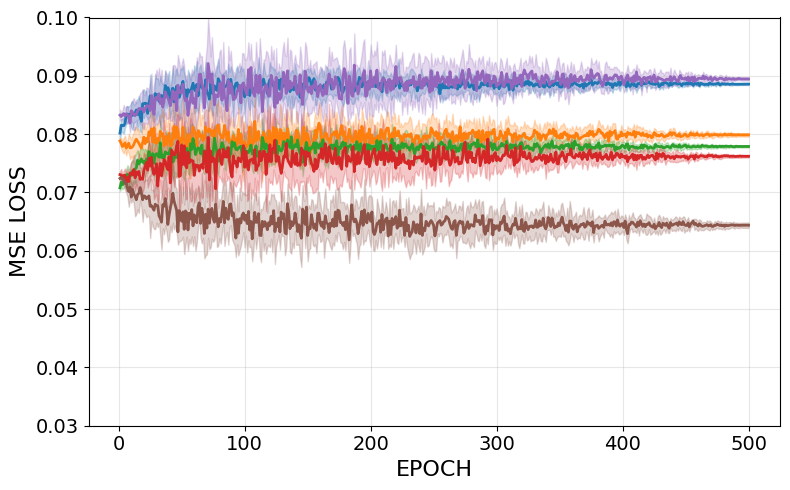


Generating figure for feature_type=both, k=50...
  Saved: texture_k50_both.pdf -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


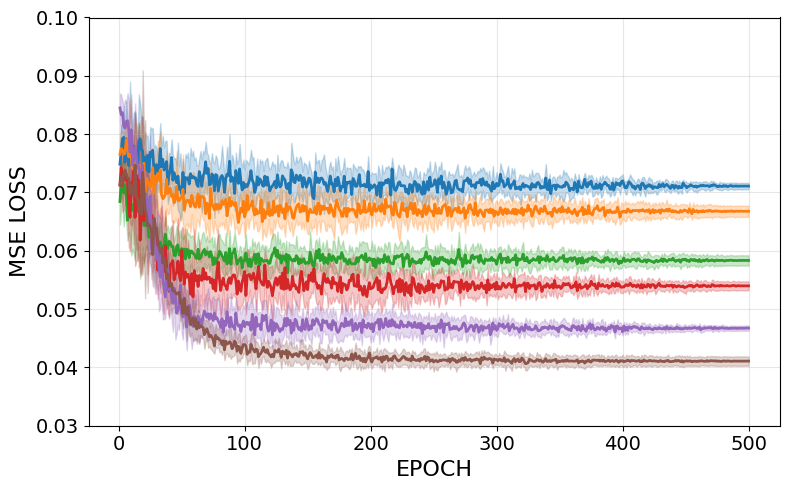

In [61]:
# Generate 2 figures for texture comparison at k=50
# Figure 1: Original (Baseline) with 10 textures
# Figure 2: Both (w/ Eigenvalues + Density) with 10 textures
SAVE_PDF = True
SAVE_DIR = os.path.join("outputs", "toydataset_order_mlp")
K_VAL = 50

try:
    api = wandb.Api()
    
    # Generate one figure per feature type
    for feature_type in ["original", "both"]:
        print(f"\nGenerating figure for feature_type={feature_type}, k={K_VAL}...")
        
        # Create base filter
        base_filter = {
            "k": K_VAL,
            "feature_type": feature_type,
            "fg_image_path": TEXTURE_FILES,
            "intensity_pos_threshold": 0.02,
            "intensity_neg_threshold": 0.02,
        }
        
        # Plot using plot_metric_over_epochs
        plot_metric_over_epochs(
            api=api,
            entity=ENTITY,
            project=PROJECT,
            base_filter=base_filter,
            metric=METRIC,
            range_type=RANGE_TYPE,
            include_fill=INCLUDE_FILL,
            alpha=ALPHA,
            linewidth=LINEWIDTH,
            figsize=FIGSIZE,
            title=None,  # No title
            grid=GRID,
            show_legend=False,  # No legend to avoid crowding
            color_by_key="fg_image_path",
            color_palette=TEXTURE_COLOR_DICT,
            label_map=None,  # No label mapping needed
            fontsize_title=FONTSIZE_TITLE,
            fontsize_labels=FONTSIZE_LABELS,
            fontsize_ticks=FONTSIZE_TICKS,
            fontsize_legend=FONTSIZE_LEGEND,
            ylim=(0.03, 0.10),
            x_axis="epoch",
            x_label="EPOCH",
            y_label="MSE LOSS",
            use_cache=USE_CACHE,
            refresh_cache=REFRESH_CACHE,
            cache_dir=CACHE_DIR,
        )
        
        # Save figure
        feature_label = LABEL_MAP.get(feature_type, feature_type).replace(" ", "_").replace("/", "_")
        filename = f"texture_k{K_VAL}_{feature_type}"
        
        if SAVE_PDF or SAVE_PNG:
            save_current_figure(
                save_dir=SAVE_DIR,
                save_name=filename,
                save_png=SAVE_PNG,
                save_pdf=SAVE_PDF,
                timestamp=False,
            )
            print(f"  Saved: {filename}.pdf -> {os.path.abspath(SAVE_DIR)}")
        
        plt.show()
        plt.close()
        
except Exception as e:
    print(f"Error generating texture comparison figures: {e}")
    import traceback
    traceback.print_exc()

## Generate Results Table

Create a table showing final validation MSE loss for each texture, with rows for "original", "both", and improvement.

In [62]:
# Generate results table with final validation MSE loss
import numpy as np
from wandb_plot_utils import fetch_runs, collect_metric_arrays, make_cache_key, get_cache_file, load_cached_arrays

K_VAL = 50
OUTPUT_DIR = os.path.join("outputs", "toydataset_order_mlp")

try:
    api = wandb.Api()
    
    # Storage for results
    results = {}  # {texture: {feature_type: {'mean': val, 'std': val, 'runs': [...]}}}
    all_runs_data = {'original': [], 'both': []}  # Store all individual run values
    
    # Collect final validation loss for each texture and feature type
    for texture in TEXTURE_FILES:
        texture_name = TEXTURE_LABEL_MAP[texture]
        results[texture_name] = {}
        
        for feature_type in ["original", "both"]:
            config = {
                "k": K_VAL,
                "feature_type": feature_type,
                "fg_image_path": texture,
                "intensity_pos_threshold": 0.02,
                "intensity_neg_threshold": 0.02,
            }
            
            # Try to load from cache first
            cache_key = make_cache_key(ENTITY, PROJECT, config, METRIC)
            cache_path = get_cache_file(CACHE_DIR, cache_key)
            arr_epochs = load_cached_arrays(cache_path)
            
            if arr_epochs is not None:
                arr, epochs = arr_epochs
                # Get final epoch values for all seeds/runs
                final_values = arr[:, -1]  # last epoch for all seeds
                final_mean = np.nanmean(final_values)
                final_std = np.nanstd(final_values)
                results[texture_name][feature_type] = {
                    'mean': final_mean,
                    'std': final_std,
                    'runs': final_values
                }
                # Store all individual run values for overall calculation
                all_runs_data[feature_type].extend(final_values[~np.isnan(final_values)])
                print(f"Loaded from cache: {texture_name}, {feature_type}: {final_mean:.6f} ± {final_std:.6f}")
            else:
                # Fetch from W&B if not cached
                runs = fetch_runs(api, ENTITY, PROJECT, config)
                if len(runs) > 0:
                    out = collect_metric_arrays(runs, METRIC, x_axis="epoch")
                    if out is not None:
                        arr, epochs = out
                        final_values = arr[:, -1]
                        final_mean = np.nanmean(final_values)
                        final_std = np.nanstd(final_values)
                        results[texture_name][feature_type] = {
                            'mean': final_mean,
                            'std': final_std,
                            'runs': final_values
                        }
                        all_runs_data[feature_type].extend(final_values[~np.isnan(final_values)])
                        print(f"Fetched from W&B: {texture_name}, {feature_type}: {final_mean:.6f} ± {final_std:.6f}")
                    else:
                        print(f"No data: {texture_name}, {feature_type}")
                else:
                    print(f"No runs: {texture_name}, {feature_type}")
    
    # Calculate overall statistics (across all runs for all textures)
    overall_original_mean = np.mean(all_runs_data['original'])
    overall_original_std = np.std(all_runs_data['original'])
    overall_both_mean = np.mean(all_runs_data['both'])
    overall_both_std = np.std(all_runs_data['both'])
    overall_improvement = overall_original_mean - overall_both_mean  # Difference, not percentage
    overall_improvement_pct = (overall_improvement / overall_original_mean) * 100  # Percentage
    
    # Build tables
    texture_names = list(results.keys())
    
    # Markdown table
    md_lines = []
    md_lines.append("| Feature Type | " + " | ".join(texture_names) + " | Overall (Mean ± Std) |")
    md_lines.append("|" + "-" * 14 + "|" + "|".join(["-" * (len(t) + 2) for t in texture_names]) + "| " + "-" * 22 + "|")
    
    # Original row
    orig_row = "| Original | "
    orig_row += " | ".join([f"{results[t]['original']['mean']:.4f} ± {results[t]['original']['std']:.4f}" for t in texture_names])
    orig_row += f" | {overall_original_mean:.4f} ± {overall_original_std:.4f} |"
    md_lines.append(orig_row)
    
    # Both row
    both_row = "| Both | "
    both_row += " | ".join([f"{results[t]['both']['mean']:.4f} ± {results[t]['both']['std']:.4f}" for t in texture_names])
    both_row += f" | {overall_both_mean:.4f} ± {overall_both_std:.4f} |"
    md_lines.append(both_row)
    
    # Improvement row (with percentage in parentheses before difference)
    improve_row = "| Improvement | "
    improvements = []
    improvement_pcts = []
    for t in texture_names:
        improvement = results[t]['original']['mean'] - results[t]['both']['mean']
        improvement_pct = (improvement / results[t]['original']['mean']) * 100
        improvements.append(improvement)
        improvement_pcts.append(improvement_pct)
        improve_row += f"({improvement_pct:.2f}%) {improvement:.4f} | "
    improve_row += f"({overall_improvement_pct:.2f}%) {overall_improvement:.4f} |"
    md_lines.append(improve_row)
    
    md_table = "\n".join(md_lines)
    
    # LaTeX table
    latex_lines = []
    latex_lines.append("\\begin{table}[htbp]")
    latex_lines.append("\\centering")
    latex_lines.append("\\caption{Final Validation MSE Loss for Different Textures (k=50)}")
    latex_lines.append("\\label{tab:texture_results}")
    
    # Build column specification
    num_cols = len(texture_names) + 2  # textures + feature type + overall
    col_spec = "l" + "c" * (num_cols - 1)
    latex_lines.append(f"\\begin{{tabular}}{{{col_spec}}}")
    latex_lines.append("\\hline")
    
    # Header
    header = "Feature Type & " + " & ".join(texture_names) + " & Overall (Mean $\\pm$ Std) \\\\"
    latex_lines.append(header)
    latex_lines.append("\\hline")
    
    # Original row
    orig_latex = "Original & "
    orig_latex += " & ".join([f"${results[t]['original']['mean']:.4f} \\pm {results[t]['original']['std']:.4f}$" for t in texture_names])
    orig_latex += f" & ${overall_original_mean:.4f} \\pm {overall_original_std:.4f}$ \\\\"
    latex_lines.append(orig_latex)
    
    # Both row
    both_latex = "Both & "
    both_latex += " & ".join([f"${results[t]['both']['mean']:.4f} \\pm {results[t]['both']['std']:.4f}$" for t in texture_names])
    both_latex += f" & ${overall_both_mean:.4f} \\pm {overall_both_std:.4f}$ \\\\"
    latex_lines.append(both_latex)
    
    # Improvement row (with percentage in parentheses)
    improve_latex = "Improvement & "
    improve_latex += " & ".join([f"({pct:.2f}\\%) {imp:.4f}" for pct, imp in zip(improvement_pcts, improvements)])
    improve_latex += f" & ({overall_improvement_pct:.2f}\\%) {overall_improvement:.4f} \\\\"
    latex_lines.append(improve_latex)
    
    latex_lines.append("\\hline")
    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")
    
    latex_table = "\n".join(latex_lines)
    
    # Save tables
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    md_file = os.path.join(OUTPUT_DIR, "texture_results.md")
    with open(md_file, "w") as f:
        f.write("# Texture Comparison Results (k=50)\n\n")
        f.write(md_table)
    print(f"\nMarkdown table saved to: {md_file}")
    
    latex_file = os.path.join(OUTPUT_DIR, "texture_results.tex")
    with open(latex_file, "w") as f:
        f.write(latex_table)
    print(f"LaTeX table saved to: {latex_file}")
    
    # Display markdown table
    print("\n" + "="*80)
    print("MARKDOWN TABLE:")
    print("="*80)
    print(md_table)
    
    print("\n" + "="*80)
    print("LATEX TABLE:")
    print("="*80)
    print(latex_table)
    
except Exception as e:
    print(f"Error generating results table: {e}")
    import traceback
    traceback.print_exc()

Loaded from cache: stratified-0106, original: 0.088581 ± 0.000162
Loaded from cache: stratified-0106, both: 0.071091 ± 0.000550
Loaded from cache: flecked-0103, original: 0.079875 ± 0.000294
Loaded from cache: flecked-0103, both: 0.066769 ± 0.000967
Loaded from cache: waffled-0063, original: 0.077886 ± 0.000181
Loaded from cache: waffled-0063, both: 0.058338 ± 0.000876
Loaded from cache: crosshatched-0066, original: 0.076200 ± 0.000219
Loaded from cache: crosshatched-0066, both: 0.053981 ± 0.000765
Loaded from cache: woven-0053, original: 0.089460 ± 0.000272
Loaded from cache: woven-0053, both: 0.046746 ± 0.000445
Loaded from cache: spiralled-0137, original: 0.064379 ± 0.000453
Loaded from cache: spiralled-0137, both: 0.041081 ± 0.000795

Markdown table saved to: outputs/toydataset_order_mlp/texture_results.md
LaTeX table saved to: outputs/toydataset_order_mlp/texture_results.tex

MARKDOWN TABLE:
| Feature Type | stratified-0106 | flecked-0103 | waffled-0063 | crosshatched-0066 | woven

In [63]:
# Fix: Rewrite the files with proper formatting
md_file = os.path.join(OUTPUT_DIR, "texture_results.md")
latex_file = os.path.join(OUTPUT_DIR, "texture_results.tex")

# Rewrite markdown file
with open(md_file, "w") as f:
    f.write("# Texture Comparison Results (k=50)\n\n")
    f.write(md_table + "\n")

print(f"Fixed markdown file: {md_file}")

# Rewrite LaTeX file
with open(latex_file, "w") as f:
    f.write(latex_table + "\n")

print(f"Fixed LaTeX file: {latex_file}")

Fixed markdown file: outputs/toydataset_order_mlp/texture_results.md
Fixed LaTeX file: outputs/toydataset_order_mlp/texture_results.tex


In [64]:
# Project selection and available config options (run this first)
ENTITY = "haraghi"
PROJECT = "knn-mlp-order-shot-noise-intensity"
OPTIONS_CACHE_DIR = "cache"
CONFIG_KEYS_TO_SCAN = None    # e.g., ["lr", "k", "feature_type"] or None for all keys
UPDATE_CONFIG_OPTIONS = False # set True to refresh from server
MAX_RUNS_TO_SCAN = None       # optional limit for speed

try:
    api = wandb.Api()
    options = update_and_get_config_options(
        api=api,
        entity=ENTITY,
        project=PROJECT,
        cache_dir=OPTIONS_CACHE_DIR,
        force_refresh=UPDATE_CONFIG_OPTIONS,
        config_keys=CONFIG_KEYS_TO_SCAN,
        max_runs=MAX_RUNS_TO_SCAN,
    )
    print("Available config options with multiple values (from cache unless refreshed):")
    print_config_options(options, min_values=2)
except Exception as e:
    print(f"Error while retrieving config options: {e}")

Available config options with multiple values (from cache unless refreshed):
K:
  - 100
  - 200
  - 50
dataset_config:
  - {'animation_fps': 10, 'animation_frame_step': 10, 'background_texture': None, 'bg_image_path': None, 'dtd_root': 'data/dtd/images', 'dtd_texture_mode': 'both', 'event_accumulation_ms': 10, 'event_animation_fps': 10, 'event_generation_method': 'intensity', 'fg_image_path': None, 'filter_size': 7, 'foreground_texture': None, 'frame_time_us': 1000, 'image_height': 256, 'image_width': 256, 'inner_radius': 20, 'intensity_neg_threshold': 0.05, 'intensity_pos_threshold': 0.05, 'intensity_shot_noise_rate_hz': 0, 'num_points': 5, 'number_of_rotations': 2, 'outer_radius': 40, 'random_seed': 0, 'shape_class': 'star8', 'tau': 30, 'total_frames': 2000, 'use_random_dtd_texture': False, 'v2e_bg_brightness': 1, 'v2e_bg_gamma': 0.6, 'v2e_cutoff_hz': 0, 'v2e_fg_brightness': 1, 'v2e_fg_gamma': 2, 'v2e_leak_jitter_fraction': 0, 'v2e_leak_rate_hz': 0, 'v2e_neg_thres': 0.2, 'v2e_noise_r

## Shot Noise Comparison Experiment

Generate 2 figures (one per feature type) comparing 4 different shot noise rates (0, 5, 20, 50 Hz) at k=50.

In [65]:
# Generate color palette for shot noise experiment
import matplotlib.colors as mcolors

def generate_shot_noise_colors():
    """Generate distinct colors for each shot noise rate."""
    
    shot_noise_rates = [0, 5, 20, 50]
    
    # Use a colormap with distinct colors
    cmap = plt.cm.get_cmap('tab10')
    
    color_dict = {}
    for i, rate in enumerate(shot_noise_rates):
        color = mcolors.to_hex(cmap(i))
        color_dict[rate] = color
    
    return color_dict, shot_noise_rates

SHOT_NOISE_COLOR_DICT, SHOT_NOISE_RATES = generate_shot_noise_colors()

# Create label map for shot noise rates
SHOT_NOISE_LABEL_MAP = {
    0: "0 Hz",
    5: "5 Hz",
    20: "20 Hz",
    50: "50 Hz",
}

print(f"Generated {len(SHOT_NOISE_COLOR_DICT)} colors for shot noise rates")
print(f"Shot noise rates: {SHOT_NOISE_RATES}")

Generated 4 colors for shot noise rates
Shot noise rates: [0, 5, 20, 50]


/data/apptainer-tmp/ipykernel_60435/3385819285.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


Computing global y-axis range for shot noise figures...
Global y-axis range: [0.0009, 0.1104]

Generating figure for feature_type=original, k=50...
  Saved: shot_noise_k50_original.pdf -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


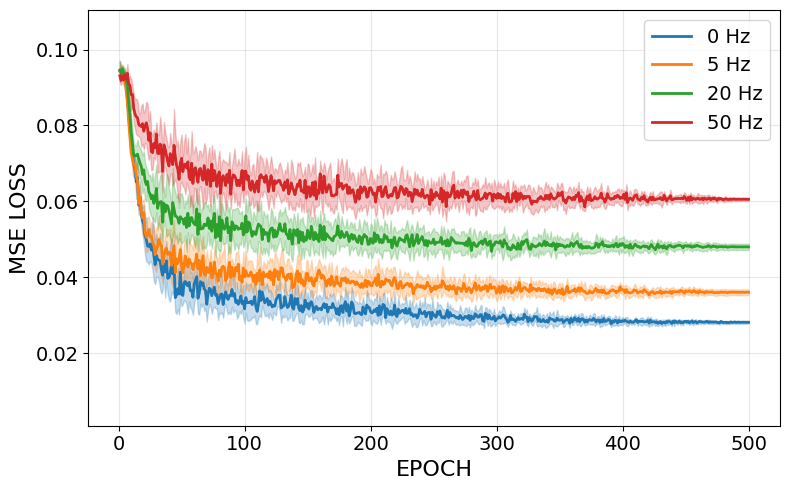


Generating figure for feature_type=both, k=50...
  Saved: shot_noise_k50_both.pdf -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


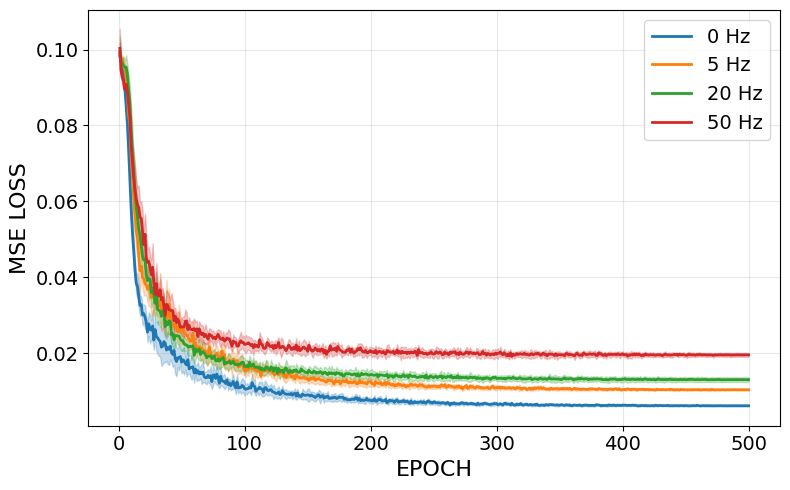

In [66]:
# Generate 2 figures for shot noise comparison at k=50
# Figure 1: Original (Baseline) with 4 shot noise rates
# Figure 2: Both (w/ Eigenvalues + Density) with 4 shot noise rates
SAVE_PDF = True
SAVE_DIR = os.path.join("outputs", "toydataset_order_mlp")
K_VAL = 50

try:
    api = wandb.Api()
    
    # Compute global y-axis range first
    print("Computing global y-axis range for shot noise figures...")
    flat_configs = []
    for rate in SHOT_NOISE_RATES:
        for feature_type in ["original", "both"]:
            flat_configs.append({
                "k": K_VAL,
                "feature_type": feature_type,
                "intensity_shot_noise_rate_hz": rate,
            })
    
    global_ymin, global_ymax = compute_global_metric_range(
        api=api,
        entity=ENTITY,
        project=PROJECT,
        config_list=flat_configs,
        metric=METRIC,
        range_type=RANGE_TYPE,
        use_cache=USE_CACHE,
        refresh_cache=REFRESH_CACHE,
        cache_dir=CACHE_DIR,
        margin=0.05,
    )
    
    if global_ymin is not None and global_ymax is not None:
        print(f"Global y-axis range: [{global_ymin:.4f}, {global_ymax:.4f}]")
    else:
        print("Could not compute global range, using auto-scaling per plot")
        global_ymin, global_ymax = None, None
    
    # Generate one figure per feature type
    for feature_type in ["original", "both"]:
        print(f"\nGenerating figure for feature_type={feature_type}, k={K_VAL}...")
        
        # Create base filter
        base_filter = {
            "k": K_VAL,
            "feature_type": feature_type,
            "intensity_shot_noise_rate_hz": SHOT_NOISE_RATES,
        }
        
        # Plot using plot_metric_over_epochs
        plot_metric_over_epochs(
            api=api,
            entity=ENTITY,
            project=PROJECT,
            base_filter=base_filter,
            metric=METRIC,
            range_type=RANGE_TYPE,
            include_fill=INCLUDE_FILL,
            alpha=ALPHA,
            linewidth=LINEWIDTH,
            figsize=FIGSIZE,
            title=None,
            grid=GRID,
            show_legend=True,
            color_by_key="intensity_shot_noise_rate_hz",
            color_palette=SHOT_NOISE_COLOR_DICT,
            label_map=SHOT_NOISE_LABEL_MAP,
            fontsize_title=FONTSIZE_TITLE,
            fontsize_labels=FONTSIZE_LABELS,
            fontsize_ticks=FONTSIZE_TICKS,
            fontsize_legend=FONTSIZE_LEGEND,
            ylim=(global_ymin, global_ymax) if global_ymin is not None else None,
            x_axis="epoch",
            x_label="EPOCH",
            y_label="MSE LOSS",
            legend_loc='best',
            use_cache=USE_CACHE,
            refresh_cache=REFRESH_CACHE,
            cache_dir=CACHE_DIR,
        )
        
        # Save figure
        filename = f"shot_noise_k{K_VAL}_{feature_type}"
        
        if SAVE_PDF or SAVE_PNG:
            save_current_figure(
                save_dir=SAVE_DIR,
                save_name=filename,
                save_png=SAVE_PNG,
                save_pdf=SAVE_PDF,
                timestamp=False,
            )
            print(f"  Saved: {filename}.pdf -> {os.path.abspath(SAVE_DIR)}")
        
        plt.show()
        plt.close()
        
except Exception as e:
    print(f"Error generating shot noise comparison figures: {e}")
    import traceback
    traceback.print_exc()


Generating combined figure with both feature types at k=50...
  Saved: shot_noise_k50_combined.pdf -> /data/idnet/toy_datasets/outputs/toydataset_order_mlp


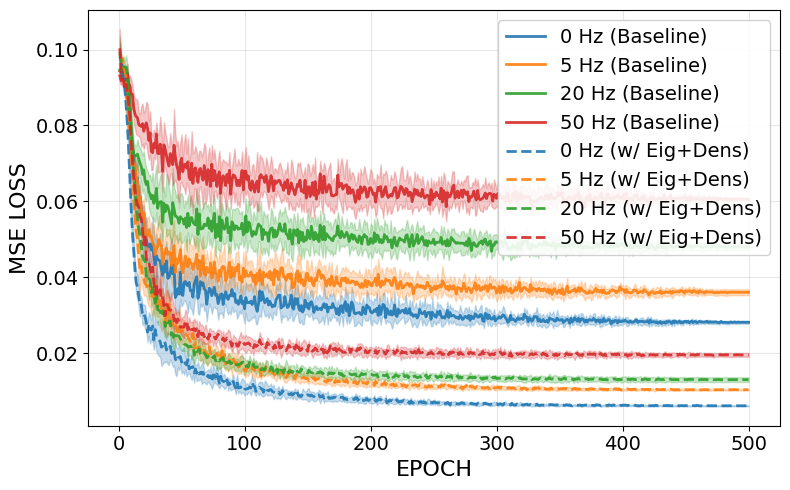

In [67]:
# Generate combined figure with both original and both feature types
SAVE_PDF = True
SAVE_DIR = os.path.join("outputs", "toydataset_order_mlp")
K_VAL = 50

try:
    api = wandb.Api()
    
    print(f"\nGenerating combined figure with both feature types at k={K_VAL}...")
    
    # Create base filter with both feature types
    base_filter = {
        "k": K_VAL,
        "feature_type": ["original", "both"],
        "intensity_shot_noise_rate_hz": SHOT_NOISE_RATES,
    }
    
    # Create custom color palette combining shot noise colors with feature type distinction
    # We'll use a nested approach: color by shot noise rate, linestyle by feature type
    combined_color_dict = {}
    for rate in SHOT_NOISE_RATES:
        rate_label = SHOT_NOISE_LABEL_MAP[rate]
        # For each rate, we'll have two entries: one for original, one for both
        combined_color_dict[f"{rate}_original"] = SHOT_NOISE_COLOR_DICT[rate]
        combined_color_dict[f"{rate}_both"] = SHOT_NOISE_COLOR_DICT[rate]
    
    # Plot using plot_metric_over_epochs with feature_type coloring
    fig, ax = plt.subplots(figsize=FIGSIZE)
    
    # Plot each combination manually to control line styles
    for feature_type in ["original", "both"]:
        for rate in SHOT_NOISE_RATES:
            rate_label = SHOT_NOISE_LABEL_MAP[rate]
            config = {
                "k": K_VAL,
                "feature_type": feature_type,
                "intensity_shot_noise_rate_hz": rate,
            }
            
            # Fetch data using the utility functions
            from wandb_plot_utils import fetch_runs, collect_metric_arrays
            runs = fetch_runs(api, ENTITY, PROJECT, config)
            
            if len(runs) > 0:
                out = collect_metric_arrays(runs, METRIC, x_axis="epoch")
                if out is not None:
                    arr, epochs = out
                    mean_vals = np.nanmean(arr, axis=0)
                    std_vals = np.nanstd(arr, axis=0)
                    
                    # Choose line style based on feature type
                    linestyle = '-' if feature_type == 'original' else '--'
                    label = f"{rate_label} ({'Baseline' if feature_type == 'original' else 'w/ Eig+Dens'})"
                    
                    ax.plot(epochs, mean_vals, 
                           color=SHOT_NOISE_COLOR_DICT[rate],
                           linestyle=linestyle,
                           linewidth=LINEWIDTH,
                           label=label,
                           alpha=0.9)
                    
                    if INCLUDE_FILL:
                        ax.fill_between(epochs, 
                                       mean_vals - std_vals, 
                                       mean_vals + std_vals,
                                       color=SHOT_NOISE_COLOR_DICT[rate],
                                       alpha=ALPHA)
    
    # Configure plot
    ax.set_xlabel("EPOCH", fontsize=FONTSIZE_LABELS)
    ax.set_ylabel("MSE LOSS", fontsize=FONTSIZE_LABELS)
    ax.tick_params(labelsize=FONTSIZE_TICKS)
    ax.grid(GRID, alpha=0.3)
    
    # Set y-axis limits if computed
    if global_ymin is not None and global_ymax is not None:
        ax.set_ylim(global_ymin, global_ymax)
    
    # Add legend
    ax.legend(fontsize=FONTSIZE_LEGEND, loc='best', framealpha=0.9)
    
    plt.tight_layout()
    
    # Save figure
    filename = f"shot_noise_k{K_VAL}_combined"
    
    if SAVE_PDF or SAVE_PNG:
        save_current_figure(
            save_dir=SAVE_DIR,
            save_name=filename,
            save_png=SAVE_PNG,
            save_pdf=SAVE_PDF,
            timestamp=False,
        )
        print(f"  Saved: {filename}.pdf -> {os.path.abspath(SAVE_DIR)}")
    
    plt.show()
    plt.close()
        
except Exception as e:
    print(f"Error generating combined shot noise figure: {e}")
    import traceback
    traceback.print_exc()

## Generate Shot Noise Results Table

Create a table showing final validation MSE loss for each shot noise rate, with rows for "original", "both", and improvement.

In [68]:
# Generate results table with final validation MSE loss for shot noise
import numpy as np
from wandb_plot_utils import fetch_runs, collect_metric_arrays, make_cache_key, get_cache_file, load_cached_arrays

K_VAL = 50
OUTPUT_DIR = os.path.join("outputs", "toydataset_order_mlp")

try:
    api = wandb.Api()
    
    # Storage for results
    results = {}  # {rate: {feature_type: {'mean': val, 'std': val, 'runs': [...]}}}
    all_runs_data = {'original': [], 'both': []}  # Store all individual run values
    
    # Collect final validation loss for each shot noise rate and feature type
    for rate in SHOT_NOISE_RATES:
        rate_label = SHOT_NOISE_LABEL_MAP[rate]
        results[rate_label] = {}
        
        for feature_type in ["original", "both"]:
            config = {
                "k": K_VAL,
                "feature_type": feature_type,
                "intensity_shot_noise_rate_hz": rate,
            }
            
            # Try to load from cache first
            cache_key = make_cache_key(ENTITY, PROJECT, config, METRIC)
            cache_path = get_cache_file(CACHE_DIR, cache_key)
            arr_epochs = load_cached_arrays(cache_path)
            
            if arr_epochs is not None:
                arr, epochs = arr_epochs
                # Get final epoch values for all seeds/runs
                final_values = arr[:, -1]  # last epoch for all seeds
                final_mean = np.nanmean(final_values)
                final_std = np.nanstd(final_values)
                results[rate_label][feature_type] = {
                    'mean': final_mean,
                    'std': final_std,
                    'runs': final_values
                }
                # Store all individual run values for overall calculation
                all_runs_data[feature_type].extend(final_values[~np.isnan(final_values)])
                print(f"Loaded from cache: {rate_label}, {feature_type}: {final_mean:.6f} ± {final_std:.6f}")
            else:
                # Fetch from W&B if not cached
                runs = fetch_runs(api, ENTITY, PROJECT, config)
                if len(runs) > 0:
                    out = collect_metric_arrays(runs, METRIC, x_axis="epoch")
                    if out is not None:
                        arr, epochs = out
                        final_values = arr[:, -1]
                        final_mean = np.nanmean(final_values)
                        final_std = np.nanstd(final_values)
                        results[rate_label][feature_type] = {
                            'mean': final_mean,
                            'std': final_std,
                            'runs': final_values
                        }
                        all_runs_data[feature_type].extend(final_values[~np.isnan(final_values)])
                        print(f"Fetched from W&B: {rate_label}, {feature_type}: {final_mean:.6f} ± {final_std:.6f}")
                    else:
                        print(f"No data: {rate_label}, {feature_type}")
                else:
                    print(f"No runs: {rate_label}, {feature_type}")
    
    # Calculate overall statistics (across all runs for all shot noise rates)
    overall_original_mean = np.mean(all_runs_data['original'])
    overall_original_std = np.std(all_runs_data['original'])
    overall_both_mean = np.mean(all_runs_data['both'])
    overall_both_std = np.std(all_runs_data['both'])
    overall_improvement = overall_original_mean - overall_both_mean  # Difference, not percentage
    overall_improvement_pct = (overall_improvement / overall_original_mean) * 100  # Percentage
    
    # Build tables
    rate_labels = list(results.keys())
    
    # Markdown table
    md_lines = []
    md_lines.append("| Feature Type | " + " | ".join(rate_labels) + " | Overall (Mean ± Std) |")
    md_lines.append("|" + "-" * 14 + "|" + "|".join(["-" * (len(r) + 2) for r in rate_labels]) + "| " + "-" * 22 + "|")
    
    # Original row
    orig_row = "| Original | "
    orig_row += " | ".join([f"{results[r]['original']['mean']:.4f} ± {results[r]['original']['std']:.4f}" for r in rate_labels])
    orig_row += f" | {overall_original_mean:.4f} ± {overall_original_std:.4f} |"
    md_lines.append(orig_row)
    
    # Both row
    both_row = "| Both | "
    both_row += " | ".join([f"{results[r]['both']['mean']:.4f} ± {results[r]['both']['std']:.4f}" for r in rate_labels])
    both_row += f" | {overall_both_mean:.4f} ± {overall_both_std:.4f} |"
    md_lines.append(both_row)
    
    # Improvement row (with percentage in parentheses before difference)
    improve_row = "| Improvement | "
    improvements = []
    improvement_pcts = []
    for r in rate_labels:
        improvement = results[r]['original']['mean'] - results[r]['both']['mean']
        improvement_pct = (improvement / results[r]['original']['mean']) * 100
        improvements.append(improvement)
        improvement_pcts.append(improvement_pct)
        improve_row += f"({improvement_pct:.2f}%) {improvement:.4f} | "
    improve_row += f"({overall_improvement_pct:.2f}%) {overall_improvement:.4f} |"
    md_lines.append(improve_row)
    
    md_table = "\n".join(md_lines)
    
    # LaTeX table
    latex_lines = []
    latex_lines.append("\\begin{table}[htbp]")
    latex_lines.append("\\centering")
    latex_lines.append("\\caption{Final Validation MSE Loss for Different Shot Noise Rates (k=50)}")
    latex_lines.append("\\label{tab:shot_noise_results}")
    
    # Build column specification
    num_cols = len(rate_labels) + 2  # rates + feature type + overall
    col_spec = "l" + "c" * (num_cols - 1)
    latex_lines.append(f"\\begin{{tabular}}{{{col_spec}}}")
    latex_lines.append("\\hline")
    
    # Header
    header = "Feature Type & " + " & ".join(rate_labels) + " & Overall (Mean $\\pm$ Std) \\\\"
    latex_lines.append(header)
    latex_lines.append("\\hline")
    
    # Original row
    orig_latex = "Original & "
    orig_latex += " & ".join([f"${results[r]['original']['mean']:.4f} \\pm {results[r]['original']['std']:.4f}$" for r in rate_labels])
    orig_latex += f" & ${overall_original_mean:.4f} \\pm {overall_original_std:.4f}$ \\\\"
    latex_lines.append(orig_latex)
    
    # Both row
    both_latex = "Both & "
    both_latex += " & ".join([f"${results[r]['both']['mean']:.4f} \\pm {results[r]['both']['std']:.4f}$" for r in rate_labels])
    both_latex += f" & ${overall_both_mean:.4f} \\pm {overall_both_std:.4f}$ \\\\"
    latex_lines.append(both_latex)
    
    # Improvement row (with percentage in parentheses)
    improve_latex = "Improvement & "
    improve_latex += " & ".join([f"({pct:.2f}\\%) {imp:.4f}" for pct, imp in zip(improvement_pcts, improvements)])
    improve_latex += f" & ({overall_improvement_pct:.2f}\\%) {overall_improvement:.4f} \\\\"
    latex_lines.append(improve_latex)
    
    latex_lines.append("\\hline")
    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")
    
    latex_table = "\n".join(latex_lines)
    
    # Save tables
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    md_file = os.path.join(OUTPUT_DIR, "shot_noise_results.md")
    with open(md_file, "w") as f:
        f.write("# Shot Noise Comparison Results (k=50)\n\n")
        f.write(md_table)
    print(f"\nMarkdown table saved to: {md_file}")
    
    latex_file = os.path.join(OUTPUT_DIR, "shot_noise_results.tex")
    with open(latex_file, "w") as f:
        f.write(latex_table)
    print(f"LaTeX table saved to: {latex_file}")
    
    # Display markdown table
    print("\n" + "="*80)
    print("MARKDOWN TABLE:")
    print("="*80)
    print(md_table)
    
    print("\n" + "="*80)
    print("LATEX TABLE:")
    print("="*80)
    print(latex_table)
    
except Exception as e:
    print(f"Error generating results table: {e}")
    import traceback
    traceback.print_exc()

Loaded from cache: 0 Hz, original: 0.028150 ± 0.000365
Loaded from cache: 0 Hz, both: 0.006170 ± 0.000139
Loaded from cache: 5 Hz, original: 0.036056 ± 0.000755
Loaded from cache: 5 Hz, both: 0.010385 ± 0.000175
Loaded from cache: 20 Hz, original: 0.048015 ± 0.000810
Loaded from cache: 20 Hz, both: 0.013044 ± 0.000614
Loaded from cache: 50 Hz, original: 0.060552 ± 0.000423
Loaded from cache: 50 Hz, both: 0.019573 ± 0.000507

Markdown table saved to: outputs/toydataset_order_mlp/shot_noise_results.md
LaTeX table saved to: outputs/toydataset_order_mlp/shot_noise_results.tex

MARKDOWN TABLE:
| Feature Type | 0 Hz | 5 Hz | 20 Hz | 50 Hz | Overall (Mean ± Std) |
|--------------|------|------|-------|-------| ----------------------|
| Original | 0.0282 ± 0.0004 | 0.0361 ± 0.0008 | 0.0480 ± 0.0008 | 0.0606 ± 0.0004 | 0.0434 ± 0.0124 |
| Both | 0.0062 ± 0.0001 | 0.0104 ± 0.0002 | 0.0130 ± 0.0006 | 0.0196 ± 0.0005 | 0.0122 ± 0.0049 |
| Improvement | (78.08%) 0.0220 | (71.20%) 0.0257 | (72.83%) 